# Matplotlib — Foundational Data Visualisation

Matplotlib is the base plotting library. Seaborn, Pandas `.plot()`, and many others are built on top of it.

Topics:
- Anatomy of a figure
- Line plots
- Bar charts
- Scatter plots
- Histograms
- Pie charts
- Subplots (multiple panels)
- Customisation: titles, labels, legends, colors, styles
- Saving figures

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

print('Matplotlib version:', mpl.__version__)

# Inline display for Jupyter
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (9, 5)

Matplotlib version: 3.10.9


## 1. Anatomy of a Figure

```
Figure  ← the whole canvas
  └── Axes  ← one plot (can have many per figure)
        ├── x-axis / y-axis
        ├── Title, xlabel, ylabel
        └── Artists: lines, bars, scatter points, text
```

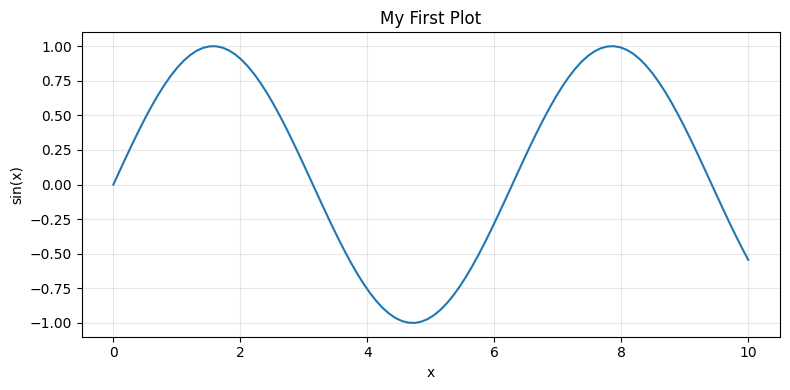

In [2]:
# The object-oriented way (recommended — explicit, flexible)
fig, ax = plt.subplots(figsize=(8, 4))

x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x))

ax.set_title('My First Plot')
ax.set_xlabel('x')
ax.set_ylabel('sin(x)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Line Plots — Trends Over Time

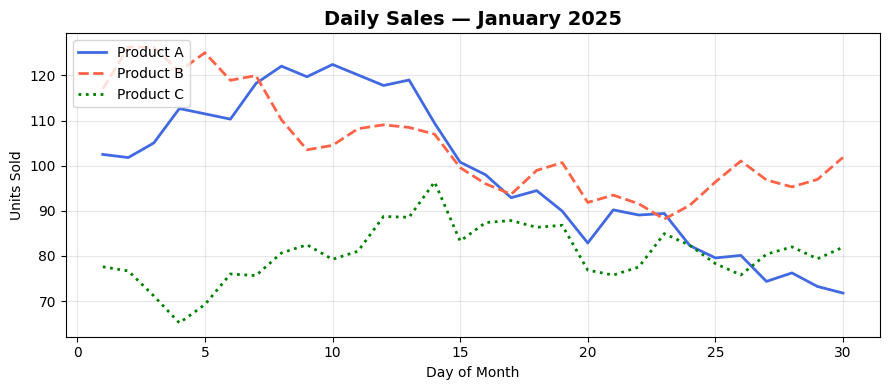

In [3]:
# Multiple lines
np.random.seed(42)
days = np.arange(1, 31)
product_a = 100 + np.cumsum(np.random.randn(30) * 5)
product_b = 120 + np.cumsum(np.random.randn(30) * 5)
product_c = 80  + np.cumsum(np.random.randn(30) * 5)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(days, product_a, label='Product A', color='royalblue', linewidth=2)
ax.plot(days, product_b, label='Product B', color='tomato',    linewidth=2, linestyle='--')
ax.plot(days, product_c, label='Product C', color='green',     linewidth=2, linestyle=':')

ax.set_title('Daily Sales — January 2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Month')
ax.set_ylabel('Units Sold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Bar Charts — Comparing Categories

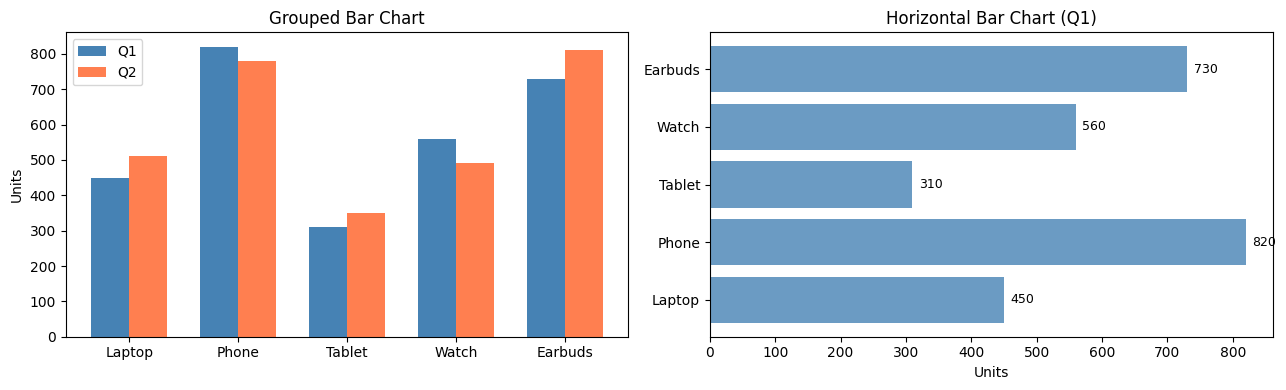

In [4]:
categories = ['Laptop', 'Phone', 'Tablet', 'Watch', 'Earbuds']
q1_sales = [450, 820, 310, 560, 730]
q2_sales = [510, 780, 350, 490, 810]

x = np.arange(len(categories))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Grouped bar chart
axes[0].bar(x - width/2, q1_sales, width, label='Q1', color='steelblue')
axes[0].bar(x + width/2, q2_sales, width, label='Q2', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_title('Grouped Bar Chart')
axes[0].legend()
axes[0].set_ylabel('Units')

# Horizontal bar chart (good for many categories)
axes[1].barh(categories, q1_sales, color='steelblue', alpha=0.8)
for i, v in enumerate(q1_sales):
    axes[1].text(v + 10, i, str(v), va='center', fontsize=9)
axes[1].set_title('Horizontal Bar Chart (Q1)')
axes[1].set_xlabel('Units')

plt.tight_layout()
plt.show()

## 3b. From-Scratch — Bar Chart from Raw `Rectangle` Patches

`ax.bar()` looks primitive but it already does real work: it computes each bar's position and
width, creates one `matplotlib.patches.Rectangle` per bar, adds every patch to the Axes, and
auto-scales the view limits to fit them. Building the same chart directly from `Rectangle`
patches shows exactly what `ax.bar()` automates.

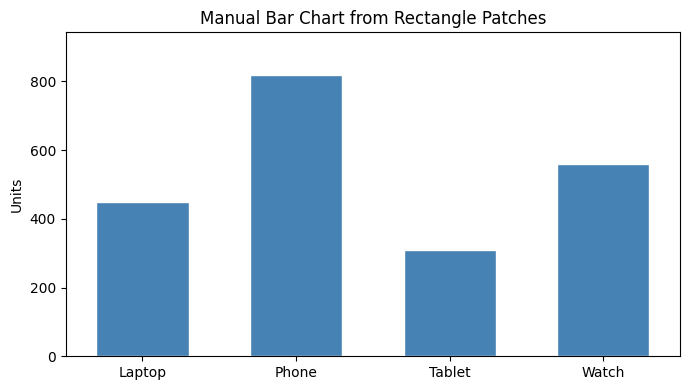

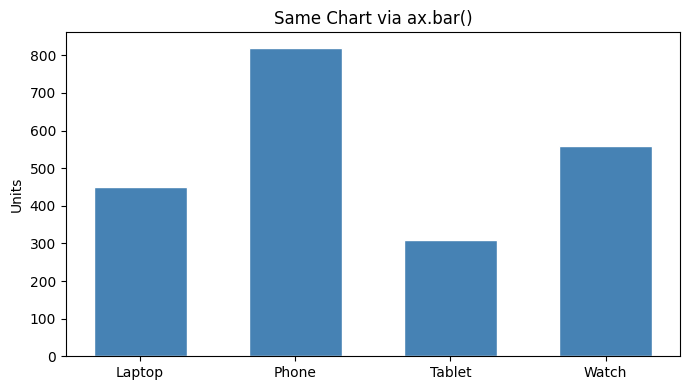

In [5]:
from matplotlib.patches import Rectangle

manual_categories = ['Laptop', 'Phone', 'Tablet', 'Watch']
manual_values = [450, 820, 310, 560]
bar_width = 0.6

fig, ax = plt.subplots(figsize=(7, 4))
for i, val in enumerate(manual_values):
    rect = Rectangle((i - bar_width / 2, 0), bar_width, val,
                      facecolor='steelblue', edgecolor='white')
    ax.add_patch(rect)   # ax.bar() does exactly this, once per bar, under the hood

# ax.bar() also auto-scales the view limits to fit its bars -- must be done by hand here
ax.set_xlim(-0.5, len(manual_categories) - 0.5)
ax.set_ylim(0, max(manual_values) * 1.15)
ax.set_xticks(range(len(manual_categories)))
ax.set_xticklabels(manual_categories)
ax.set_title('Manual Bar Chart from Rectangle Patches')
ax.set_ylabel('Units')
plt.tight_layout()
plt.show()

# Compare: ax.bar() produces the identical visual result in one call
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(manual_categories, manual_values, width=bar_width, color='steelblue', edgecolor='white')
ax.set_title('Same Chart via ax.bar()')
ax.set_ylabel('Units')
plt.tight_layout()
plt.show()

## 4. Scatter Plots — Relationships Between Variables

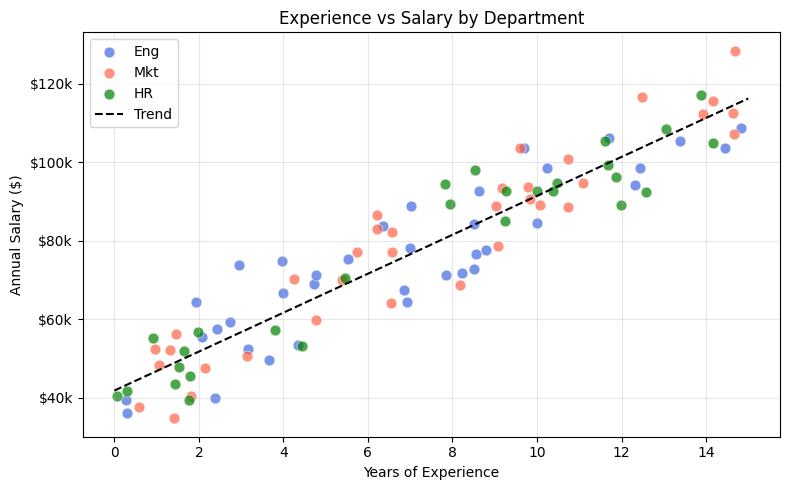

In [6]:
np.random.seed(0)
n = 100
experience = np.random.uniform(0, 15, n)
salary = 40000 + experience * 5000 + np.random.randn(n) * 8000
dept = np.random.choice(['Eng','Mkt','HR'], n)

colors = {'Eng': 'royalblue', 'Mkt': 'tomato', 'HR': 'green'}

fig, ax = plt.subplots(figsize=(8, 5))
for d in ['Eng', 'Mkt', 'HR']:
    mask = np.array([dept[i] == d for i in range(n)])
    ax.scatter(experience[mask], salary[mask],
               label=d, color=colors[d], alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

# Add regression line
z = np.polyfit(experience, salary, 1)
p = np.poly1d(z)
xl = np.linspace(0, 15, 100)
ax.plot(xl, p(xl), 'k--', linewidth=1.5, label='Trend')

ax.set_title('Experience vs Salary by Department')
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Annual Salary ($)')
ax.legend()
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Histograms — Distributions

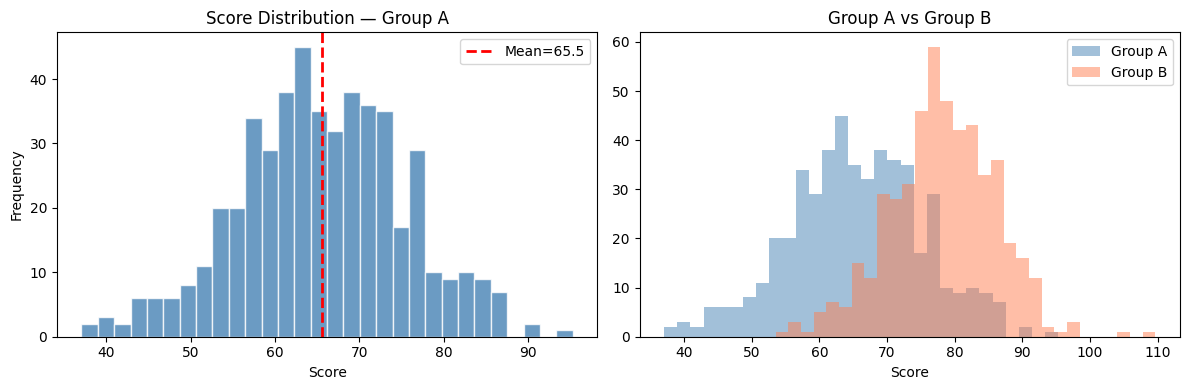

In [7]:
np.random.seed(1)
data_a = np.random.normal(65, 10, 500)
data_b = np.random.normal(78, 8,  500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Basic histogram
axes[0].hist(data_a, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(data_a.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={data_a.mean():.1f}')
axes[0].set_title('Score Distribution — Group A')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Overlapping histograms — comparing two distributions
axes[1].hist(data_a, bins=30, color='steelblue', alpha=0.5, label='Group A')
axes[1].hist(data_b, bins=30, color='coral',     alpha=0.5, label='Group B')
axes[1].set_title('Group A vs Group B')
axes[1].set_xlabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Subplots — Dashboard Layout

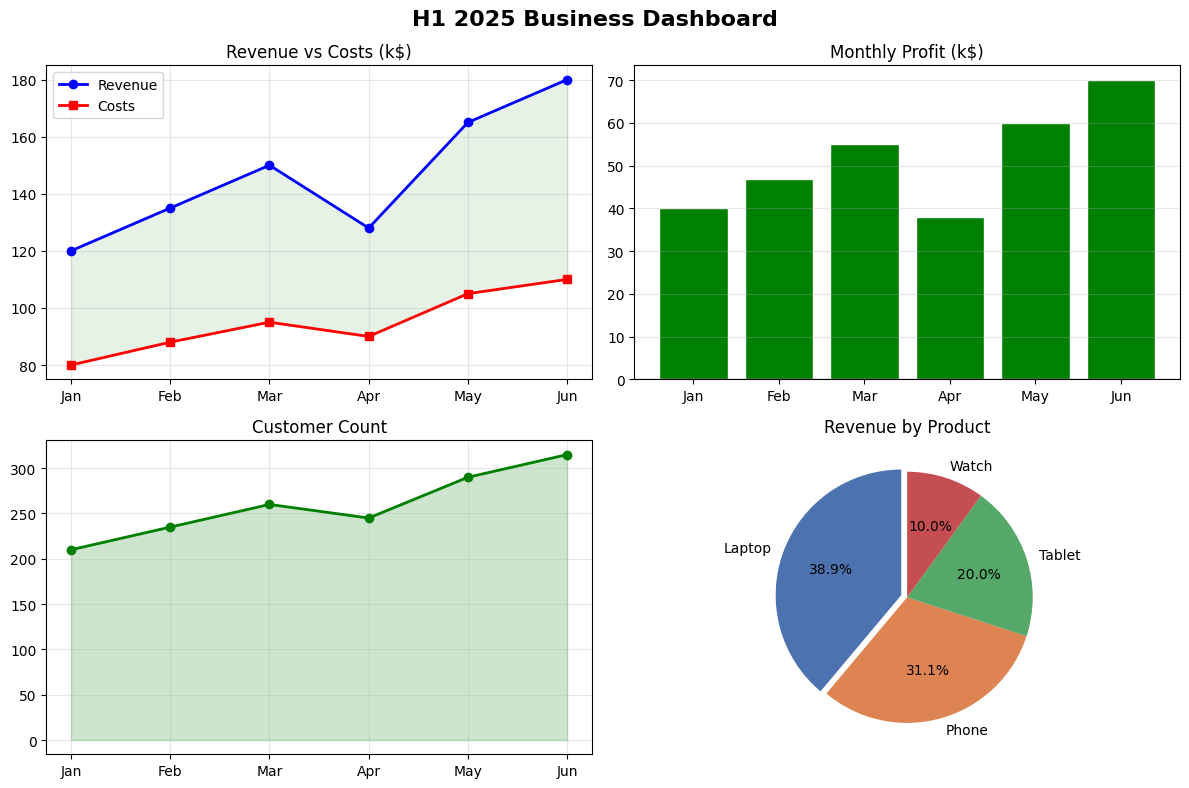

In [8]:
months = ['Jan','Feb','Mar','Apr','May','Jun']
revenue = [120, 135, 150, 128, 165, 180]
costs   = [80,  88,  95,  90, 105, 110]
profit  = [r - c for r, c in zip(revenue, costs)]
customers = [210, 235, 260, 245, 290, 315]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('H1 2025 Business Dashboard', fontsize=16, fontweight='bold')

# Revenue vs costs line chart
axes[0,0].plot(months, revenue, 'b-o', label='Revenue', linewidth=2)
axes[0,0].plot(months, costs, 'r-s', label='Costs', linewidth=2)
axes[0,0].fill_between(months, costs, revenue, alpha=0.1, color='green')
axes[0,0].set_title('Revenue vs Costs (k$)')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Profit bar chart
colors = ['green' if p >= 0 else 'red' for p in profit]
axes[0,1].bar(months, profit, color=colors, edgecolor='white')
axes[0,1].set_title('Monthly Profit (k$)')
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].grid(axis='y', alpha=0.3)

# Customer growth
axes[1,0].plot(months, customers, 'g-o', linewidth=2)
axes[1,0].fill_between(months, customers, alpha=0.2, color='green')
axes[1,0].set_title('Customer Count')
axes[1,0].grid(alpha=0.3)

# Revenue pie chart
product_revenue = [350, 280, 180, 90]
product_names   = ['Laptop', 'Phone', 'Tablet', 'Watch']
explode = (0.05, 0, 0, 0)
axes[1,1].pie(product_revenue, labels=product_names, explode=explode,
               autopct='%1.1f%%', startangle=90, colors=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1,1].set_title('Revenue by Product')

plt.tight_layout()
plt.show()

## 7. Customisation & Saving Figures

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot']


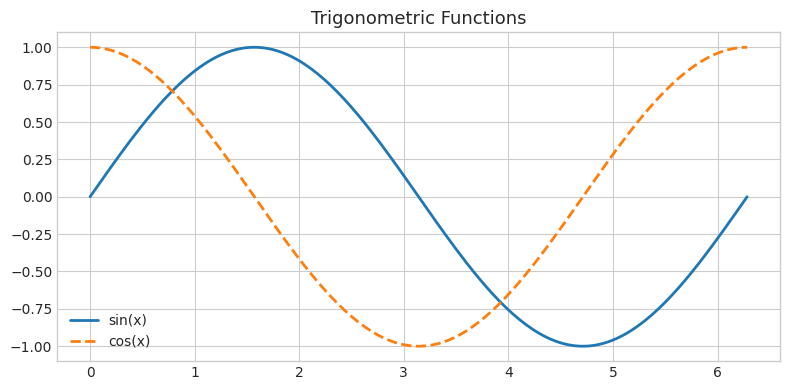

In [9]:
# Using built-in styles
print(plt.style.available[:10])

with plt.style.context('seaborn-v0_8-whitegrid'):
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.linspace(0, 2*np.pi, 200)
    ax.plot(x, np.sin(x), label='sin(x)', linewidth=2)
    ax.plot(x, np.cos(x), label='cos(x)', linewidth=2, linestyle='--')
    ax.set_title('Trigonometric Functions', fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

Saved to /tmp/revenue_chart.png


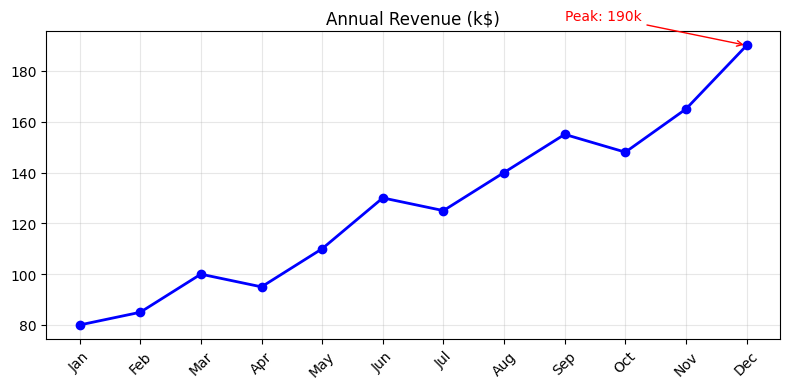

In [10]:
# Annotating a plot
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(1, 13)
revenue = [80, 85, 100, 95, 110, 130, 125, 140, 155, 148, 165, 190]
ax.plot(x, revenue, 'b-o', linewidth=2)

# Annotate the peak
peak_idx = np.argmax(revenue)
ax.annotate(f'Peak: {revenue[peak_idx]}k',
            xy=(x[peak_idx], revenue[peak_idx]),
            xytext=(x[peak_idx]-3, revenue[peak_idx]+10),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax.set_title('Annual Revenue (k$)')
ax.grid(alpha=0.3)
plt.tight_layout()

# Save to file
fig.savefig('/tmp/revenue_chart.png', dpi=150, bbox_inches='tight')
print('Saved to /tmp/revenue_chart.png')
plt.show()

## 8. Failure Modes

- **Mutating shared state via `plt.gca()`/`plt.plot()` unexpectedly in a loop.** `plt.plot()`
  implicitly targets whatever Axes Matplotlib currently considers "current" — global, mutable
  state that isn't visible at the call site.
- **Mismatched figure/dpi settings making saved images unreadable.** A figure sized for
  on-screen viewing (`figsize=(8, 5)`), saved at a very low `dpi`, becomes a tiny, illegible
  pixel image on disk even though it looked fine with `plt.show()`.

In [11]:
import os

# Failure mode 1: plt.gca() / plt.plot() target implicit global "current axes" state
fig1, ax1 = plt.subplots(figsize=(4, 3))
plt.plot([1, 2, 3], [1, 4, 9])   # implicitly plots on ax1, the "current axes"
print('plt.gca() is ax1 right after creating fig1:', plt.gca() is ax1)

fig2, ax2 = plt.subplots(figsize=(4, 3))
print('plt.gca() is ax2 right after creating fig2:', plt.gca() is ax2)
print('-> "current axes" silently changed with no call naming ax2 -- easy to plot onto the')
print('   wrong figure inside a loop that forgets which axes is now current.')
plt.close('all')

# The fix: hold the ax reference explicitly, call methods on it (ax.plot, not plt.plot)
fig3, (axA, axB) = plt.subplots(1, 2, figsize=(8, 3))
axA.plot([1, 2, 3], [1, 2, 3])
axB.plot([1, 2, 3], [3, 2, 1])
print('Explicit ax.plot() never depends on which axes plt.gca() currently considers current.')
plt.close('all')

# Failure mode 2: figsize tuned for on-screen viewing, saved at a very low dpi
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(10), np.arange(10) ** 2)
ax.set_title('Readable on screen')
fig.savefig('/tmp/low_dpi.png', dpi=20)
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(10), np.arange(10) ** 2)
ax.set_title('Readable on screen')
fig.savefig('/tmp/normal_dpi.png', dpi=150)
plt.close(fig)

import matplotlib.image as mpimg
low_pixels = mpimg.imread('/tmp/low_dpi.png').shape
normal_pixels = mpimg.imread('/tmp/normal_dpi.png').shape
print(f"\nlow dpi=20  -> saved image pixel size: {low_pixels[1]}x{low_pixels[0]}, "
      f"file bytes: {os.path.getsize('/tmp/low_dpi.png')}")
print(f"normal dpi=150 -> saved image pixel size: {normal_pixels[1]}x{normal_pixels[0]}, "
      f"file bytes: {os.path.getsize('/tmp/normal_dpi.png')}")
print('Same figsize, same content -- the low-dpi save is a fraction of the pixel resolution.')

plt.gca() is ax1 right after creating fig1: True
plt.gca() is ax2 right after creating fig2: True
-> "current axes" silently changed with no call naming ax2 -- easy to plot onto the
   wrong figure inside a loop that forgets which axes is now current.
Explicit ax.plot() never depends on which axes plt.gca() currently considers current.



low dpi=20  -> saved image pixel size: 160x100, file bytes: 2645
normal dpi=150 -> saved image pixel size: 1200x750, file bytes: 36329
Same figsize, same content -- the low-dpi save is a fraction of the pixel resolution.


## Quick Summary

| Plot Type | When to Use | Code |
|-----------|-------------|------|
| Line | Trends over time | `ax.plot(x, y)` |
| Bar | Comparing categories | `ax.bar(x, height)` |
| Horizontal bar | Many categories | `ax.barh(y, width)` |
| Scatter | Relationship between 2 vars | `ax.scatter(x, y)` |
| Histogram | Distribution of a variable | `ax.hist(data, bins=30)` |
| Pie | Part-to-whole | `ax.pie(values, labels=...)` |
| Subplots | Dashboard / multiple panels | `fig, axes = plt.subplots(r, c)` |

**Next →** [06 – Seaborn](../06-seaborn/)